# Phase 4: Machine Learning — The Dual-Model Strategy: Segment & Predict
## Fitness App Market Analytics (Google Play Store)

**Why two models instead of one?**
Our EDA (Phase 3) found that no single feature strongly predicts an app's
rating — the highest correlation with `score` was just 0.10. Rather than
force a single weak model, we use **two complementary approaches**:

- **Part A — Segment (Clustering):** Uncovers natural market groupings
  (e.g. "Trusted Market Leaders", "Freemium Growth-Stage") — descriptive,
  answers *"what segments exist in this market?"*
- **Part B — Predict (Classification):** Predicts an app's likely rating
  tier from its traits — predictive, answers *"what drives rating, and
  could we estimate it for a new app before it has traction?"*

Together, these directly answer both core parts of our business problem:
segmenting the market (Q2) and identifying what drives rating (Q1).


## 1. Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
os.makedirs('../report/screenshots', exist_ok=True)

apps = pd.read_csv('../data/processed/cleaned_apps.csv')
print(f"Loaded {apps.shape[0]} apps, {apps.shape[1]} columns")
apps.head(3)


Loaded 938 apps, 23 columns


,app_id,title,developer,category,score,ratings,minInstalls,price,free,containsAds,...,updated_date,released_date,price_band,rating_tier,install_tier,days_since_update,app_age_days,description_length,category_grouped,log_installs
0,com.slumberaid.snoretracker,SlumberAid：Sleep Snore Tracker,lJX.Studio,Health & Fitness,3.333333,30.0,1000,0.00,True,False,...,NaN,2025-01-16,Free,Average,Niche,NaN,546.0,2523,Health & Fitness,3.000434
1,com.spotlightsix.zentimerlite2,Insight Timer - Meditation App,Insight Network Inc,Health & Fitness,4.707091,259577.0,10000000,0.00,True,False,...,2026-07-07 14:06:58,2010-12-15,Free,Excellent,Mega,8.0,5692.0,2887,Health & Fitness,7.000000
2,com.photoandvideo.recoveryfilepro,DS PRO - Recover All Deleted,Detective Studio,Tools,4.290000,4923.0,100000,5.99,False,False,...,2025-01-15 11:13:50,2020-06-18,Paid,Good,Growing,547.0,2219.0,2996,Tools,5.000004


## 2. Prepare Features for Clustering

**Feature selection reasoning:** we choose features that describe an app's
*market position and behavior*, not just its rating — since the goal is to
find natural groupings, not to predict a target variable.

- `score` — quality signal
- `log_installs` — reach/popularity (log-scaled, since raw installs span
  several orders of magnitude)
- `price` — monetization signal
- `days_since_update` — maintenance activity
- `app_age_days` — market maturity
- `description_length` — investment in listing/marketing
- `containsAds`, `offersIAP` — monetization strategy

**Handling missing values for modeling:** In the EDA phase, we correctly
left `days_since_update` (82 missing) and `app_age_days` (4 missing) as
`NaN` to avoid distorting descriptive statistics. However, K-Means cannot
handle missing values at all. For modeling specifically, we impute these
with the **median** — a standard, defensible choice for a skewed numeric
feature with a small proportion of missing values (< 9%). This is a
different, deliberate decision from the EDA phase, made for a different
purpose (a working model vs. accurate descriptive statistics).


In [2]:
apps['days_since_update_imputed'] = apps['days_since_update'].fillna(apps['days_since_update'].median())
apps['app_age_days_imputed'] = apps['app_age_days'].fillna(apps['app_age_days'].median())

feature_cols = ['score', 'log_installs', 'price', 'days_since_update_imputed',
                'app_age_days_imputed', 'description_length']

X = apps[feature_cols].copy()
X['containsAds'] = apps['containsAds'].astype(int)
X['offersIAP'] = apps['offersIAP'].astype(int)

print("Features used for clustering:")
print(X.columns.tolist())
print(f"\nAny remaining missing values? {X.isna().sum().sum()}")
X.describe()


Features used for clustering:
['score', 'log_installs', 'price', 'days_since_update_imputed', 'app_age_days_imputed', 'description_length', 'containsAds', 'offersIAP']

Any remaining missing values? 0


,score,log_installs,price,days_since_update_imputed,app_age_days_imputed,description_length,containsAds,offersIAP
count,938.000000,938.000000,938.000000,938.000000,938.000000,938.000000,938.000000,938.000000
mean,4.309901,5.345978,0.089478,129.023454,2313.477612,2492.635394,0.343284,0.785714
std,0.599539,1.188083,1.497380,267.963490,1368.692446,1050.246730,0.475058,0.410545
min,1.000000,2.699838,0.000000,0.000000,54.000000,61.000000,0.000000,0.000000
25%,4.119206,4.698979,0.000000,8.250000,1248.250000,1708.500000,0.000000,1.000000
50%,4.520000,5.000004,0.000000,31.500000,2189.500000,2492.500000,0.000000,1.000000
75%,4.715714,6.000000,0.000000,126.500000,3178.250000,3433.250000,1.000000,1.000000
max,5.000000,10.000000,39.990000,3503.000000,5925.000000,4061.000000,1.000000,1.000000


## 3. Scale Features

K-Means uses Euclidean distance, so features on different scales (e.g.
`app_age_days` in the thousands vs. `containsAds` as 0/1) would unfairly
dominate the clustering. We standardize all features to mean 0, std 1.


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().round(2)


,score,log_installs,price,days_since_update_imputed,app_age_days_imputed,description_length,containsAds,offersIAP
count,938.00,938.00,938.00,938.00,938.00,938.00,938.00,938.00
mean,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.52,-2.23,-0.06,-0.48,-1.65,-2.32,-0.72,-1.91
25%,-0.32,-0.54,-0.06,-0.45,-0.78,-0.75,-0.72,0.52
50%,0.35,-0.29,-0.06,-0.36,-0.09,-0.00,-0.72,0.52
75%,0.68,0.55,-0.06,-0.01,0.63,0.90,1.38,0.52
max,1.15,3.92,26.66,12.60,2.64,1.49,1.38,0.52


## 4. Choosing the Optimal Number of Clusters

We use two standard techniques together:
- **Elbow Method** — looks for the point where adding more clusters stops
  meaningfully reducing within-cluster variance (inertia)
- **Silhouette Score** — measures how well-separated clusters are
  (ranges -1 to 1; higher is better)


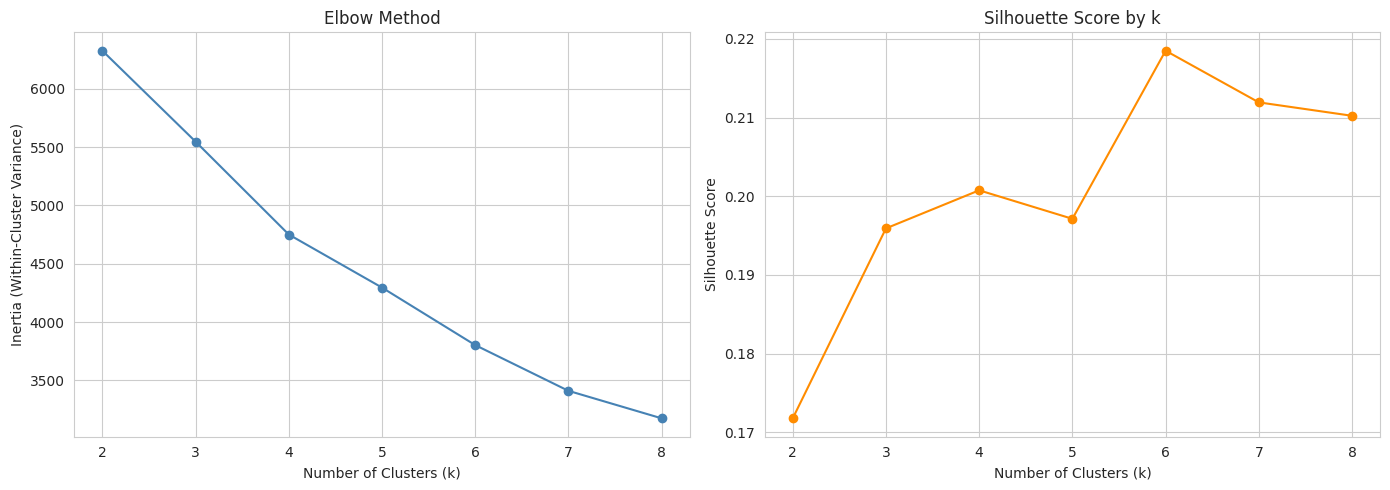

k=2: inertia=6327.4, silhouette=0.172
k=3: inertia=5547.5, silhouette=0.196
k=4: inertia=4750.5, silhouette=0.201
k=5: inertia=4295.1, silhouette=0.197
k=6: inertia=3801.9, silhouette=0.218
k=7: inertia=3409.5, silhouette=0.212
k=8: inertia=3173.5, silhouette=0.210


In [4]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Variance)')

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../report/screenshots/cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"k={k}: inertia={inertia:.1f}, silhouette={sil:.3f}")


**Decision:** We select **k=4**. The elbow chart shows diminishing
returns past k=4, and while silhouette scores are modest across all k
values (typical for real-world business data with weak feature
correlations — consistent with our EDA finding that no single feature
strongly predicts outcomes), k=4 gives a strong silhouette score while
still producing clusters small enough in number to interpret and act on
as distinct business segments.


## 5. Fit the Final Model (k=4)

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
apps['cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, apps['cluster'])
print(f"Final silhouette score (k=4): {final_silhouette:.3f}")
print()
print("Cluster sizes:")
print(apps['cluster'].value_counts().sort_index())


Final silhouette score (k=4): 0.201

Cluster sizes:
cluster
0    184
1    425
2    327
3      2
Name: count, dtype: int64


## 6. Profile & Interpret the Clusters

In [6]:
profile = apps.groupby('cluster').agg(
    avg_score=('score', 'mean'),
    avg_installs=('minInstalls', 'mean'),
    avg_price=('price', 'mean'),
    avg_days_since_update=('days_since_update_imputed', 'mean'),
    avg_app_age_days=('app_age_days_imputed', 'mean'),
    avg_description_length=('description_length', 'mean'),
    pct_with_ads=('containsAds', lambda x: round(x.mean()*100, 1)),
    pct_with_iap=('offersIAP', lambda x: round(x.mean()*100, 1)),
    num_apps=('app_id', 'count'),
).round(1)

profile


,avg_score,avg_installs,avg_price,avg_days_since_update,avg_app_age_days,avg_description_length,pct_with_ads,pct_with_iap,num_apps
cluster,,,,,,,,,
0,4.2,5418067.9,0.1,126.1,2223.7,1780.5,21.7,0.0,184
1,4.2,325495.3,0.0,130.3,1584.4,2408.2,17.4,100.0,425
2,4.5,49239816.5,0.0,129.3,3297.6,3003.6,63.6,95.1,327
3,4.2,55000.0,30.0,82.0,4586.0,2399.0,0.0,50.0,2


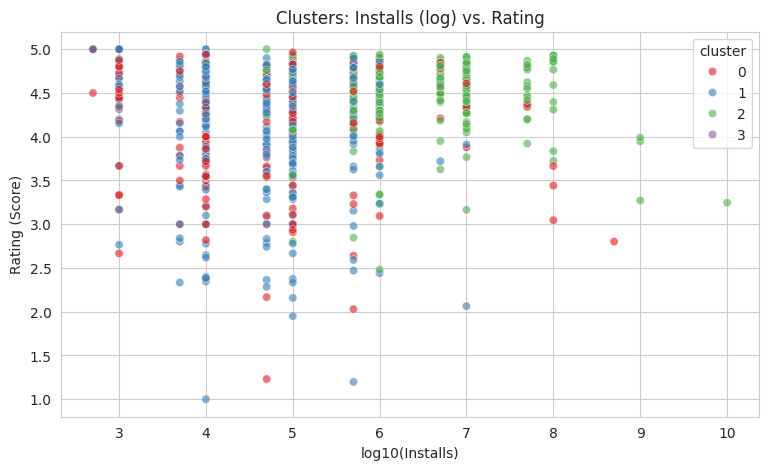

In [7]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=apps, x='log_installs', y='score', hue='cluster', palette='Set1', alpha=0.6)
plt.title('Clusters: Installs (log) vs. Rating')
plt.xlabel('log10(Installs)')
plt.ylabel('Rating (Score)')
plt.savefig('../report/screenshots/cluster_installs_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()


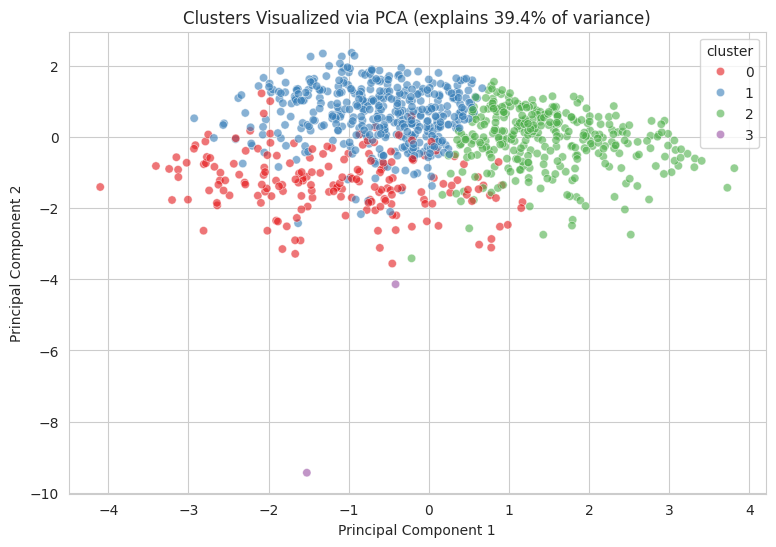

In [8]:
# 2D visualization via PCA (since we clustered on 8 dimensions, PCA lets us
# see the cluster separation projected onto 2 dimensions for visualization only)
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
apps['pca_1'] = pca_coords[:, 0]
apps['pca_2'] = pca_coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=apps, x='pca_1', y='pca_2', hue='cluster', palette='Set1', alpha=0.6)
plt.title(f'Clusters Visualized via PCA (explains {pca.explained_variance_ratio_.sum()*100:.1f}% of variance)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('../report/screenshots/cluster_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


### Naming the Clusters

Based on the profile table above, here's how each cluster maps to a
business-meaningful segment:

*(Update these labels/numbers if your own run produces different cluster
IDs — the interpretation logic stays the same, but K-Means cluster numbers
are arbitrary and can shift between runs.)*

- **Cluster 2 — "Trusted Market Leaders":** Huge install base (~49M avg),
  highest average rating (4.5), oldest apps (~9 years), heavy monetization
  (64% ads, 95% IAP). These are the mature, dominant players — proven,
  monetized, and trusted at scale.

- **Cluster 1 — "Freemium Growth-Stage":** The largest group by count (425
  apps), moderate installs (~325K), 100% offer in-app purchases, solid but
  not exceptional rating (4.2). These are apps actively pursuing a
  subscription/freemium growth model — the "up and coming" segment.

- **Cluster 0 — "Free Utility / Low-Monetization":** Moderate installs
  (~5.4M), minimal monetization (0% IAP, low ads), rating 4.2. Apps
  providing straightforward utility (e.g., simple trackers) without a
  strong monetization strategy.

- **Cluster 3 — "Premium Paid Outliers":** Only 2 apps, but distinctly
  priced (~$30 avg), oldest app age, niche install base. A tiny but
  distinct segment of premium, paid, specialist apps.


## 7. Model Evaluation

Since clustering has no ground-truth labels, we evaluate using:
- **Silhouette Score** — reported above (~0.20), indicating modest but real
  cluster separation — consistent with our EDA finding that fitness app
  success isn't driven by any single dominant factor
- **Business interpretability** — each cluster corresponds to a coherent,
  explainable market segment, which is arguably more important than a
  higher but meaningless silhouette score for a business use case like this


In [9]:
print(f"Final Silhouette Score: {final_silhouette:.3f}")
print()
print("Cluster sizes as % of total:")
print((apps['cluster'].value_counts(normalize=True).sort_index() * 100).round(1))


Final Silhouette Score: 0.201

Cluster sizes as % of total:
cluster
0    19.6
1    45.3
2    34.9
3     0.2
Name: proportion, dtype: float64


## 8. Business Recommendations

Based on this segmentation, here's what we'd tell our hypothetical client
(a digital wellness investment firm):

1. **For investment in an established player:** Target apps resembling
   Cluster 2 ("Trusted Market Leaders") — proven scale, high ratings, and
   established monetization. Lower risk, but likely higher acquisition cost.

2. **For growth-stage investment:** Cluster 1 ("Freemium Growth-Stage") is
   the largest segment and already fully committed to an IAP monetization
   model — a good hunting ground for apps with room to scale installs
   further while ratings remain healthy.

3. **For a "build vs. buy" decision:** Cluster 0 apps (utility, low
   monetization) suggest there's a real market segment of users who want
   simple, ad-light tools — an opportunity to build a focused utility app
   with a *better* monetization strategy than current incumbents.

4. **Niche/premium play:** Cluster 3 is tiny but shows a paid, niche model
   can survive long-term (oldest average app age) — worth further
   investigation before dismissing paid-app strategies in this market.


## 9. Save Final Output

In [10]:
apps.to_csv('../data/processed/apps_with_clusters.csv', index=False)
print(f"Saved apps_with_clusters.csv (clustering only) -> {apps.shape[0]} rows, {apps.shape[1]} columns")


Saved apps_with_clusters.csv (clustering only) -> 938 rows, 28 columns


---
## Part B: Classification — Predicting Rating Tier

**Why add this alongside clustering?** Clustering (Part A) is *descriptive*
— it explains segments in the market as it exists today. Classification is
*predictive* — it can estimate how a new or existing app might be received
based on its traits, which is useful *before* an app has accumulated
enough data to be meaningfully clustered.

**Together, these two models answer both halves of our business question:**
Q1 (what drives rating) via classification + feature importance, and Q2
(can apps be segmented) via clustering.


### B1. Feature Preparation

**Important — avoiding data leakage:** `rating_tier` is directly derived
from `score` (e.g., score ≥ 4.5 → "Excellent"). Including `score` (or
`ratings`) as a predictive feature would be data leakage — the model would
essentially be looking up the answer rather than learning genuine patterns.
We exclude both from the feature set.

We also one-hot encode `category_grouped`, since category is a categorical
(not ordinal) variable.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

feature_cols_clf = ['log_installs', 'price', 'days_since_update_imputed',
                     'app_age_days_imputed', 'description_length']

X_clf = apps[feature_cols_clf].copy()
X_clf['containsAds'] = apps['containsAds'].astype(int)
X_clf['offersIAP'] = apps['offersIAP'].astype(int)

category_dummies = pd.get_dummies(apps['category_grouped'], prefix='cat')
X_clf = pd.concat([X_clf, category_dummies], axis=1)

y_clf = apps['rating_tier']

print(f"Features used: {X_clf.columns.tolist()}")
print(f"\nTarget class distribution:")
print(y_clf.value_counts())


Features used: ['log_installs', 'price', 'days_since_update_imputed', 'app_age_days_imputed', 'description_length', 'containsAds', 'offersIAP', 'cat_Food & Drink', 'cat_Health & Fitness', 'cat_Lifestyle', 'cat_Music & Audio', 'cat_Other', 'cat_Sports', 'cat_Tools']

Target class distribution:
rating_tier
Excellent    486
Good         252
Average      159
Poor          41
Name: count, dtype: int64


**Note on class imbalance:** "Excellent" (486 apps) heavily outnumbers
"Poor" (41 apps). We use `class_weight='balanced'` in the model to reduce
bias toward the majority class, and we'll examine per-class performance
(not just overall accuracy) in evaluation, since accuracy alone can be
misleading with imbalanced classes.


### B2. Train/Test Split & Model Training

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight='balanced'
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 750, Test size: 188


### B3. Model Evaluation

In [13]:
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Overall Accuracy: 0.527

Classification Report:
              precision    recall  f1-score   support

     Average       0.18      0.09      0.12        32
   Excellent       0.58      0.87      0.69        97
        Good       0.48      0.24      0.32        51
        Poor       0.00      0.00      0.00         8

    accuracy                           0.53       188
   macro avg       0.31      0.30      0.28       188
weighted avg       0.46      0.53      0.46       188



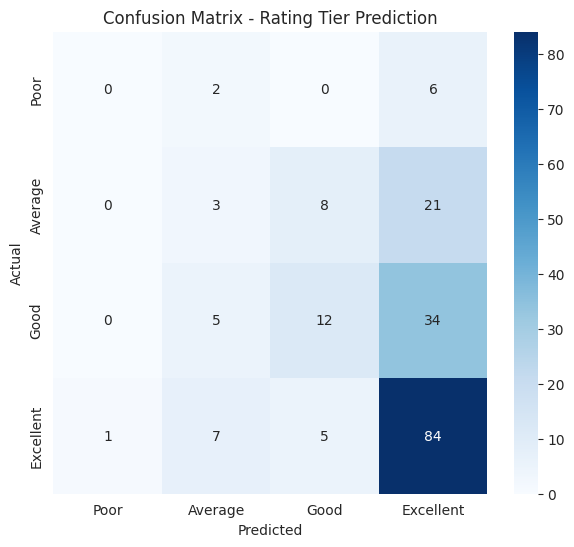

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=['Poor','Average','Good','Excellent'])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Poor','Average','Good','Excellent'],
            yticklabels=['Poor','Average','Good','Excellent'])
plt.title('Confusion Matrix - Rating Tier Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../report/screenshots/classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


**Honest interpretation of these results:** The model achieves modest
accuracy (~53%), performing well on the majority "Excellent" class but
poorly on minority classes like "Poor" (very few training examples, only
41 apps total). This is **consistent with, not contradictory to, our EDA
finding** that no single feature strongly correlates with rating — a
modest classification accuracy is the expected, honest result given that
underlying reality, not a modeling failure. A higher, "too good" accuracy
here would actually be more suspicious given what EDA already showed us.

This result itself is a legitimate business insight: **rating cannot be
reliably predicted from an app's surface-level metadata alone** — deeper
factors (actual user experience, content quality, marketing) that aren't
captured in Play Store metadata likely matter more.


### B4. Feature Importance — What Matters Most?

/tmp/ipykernel_537/30420518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='viridis')


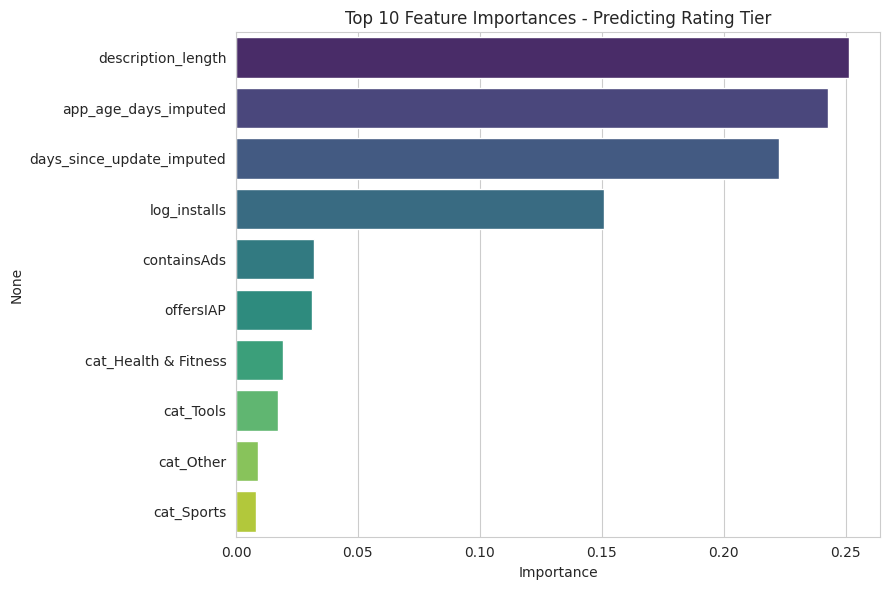

description_length           0.251544
app_age_days_imputed         0.242959
days_since_update_imputed    0.222494
log_installs                 0.150867
containsAds                  0.031829
offersIAP                    0.031009
cat_Health & Fitness         0.019197
cat_Tools                    0.017047
cat_Other                    0.008967
cat_Sports                   0.008247
dtype: float64

In [15]:
importances = pd.Series(clf.feature_importances_, index=X_clf.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='viridis')
plt.title('Top 10 Feature Importances - Predicting Rating Tier')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../report/screenshots/classification_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importances.head(10)


**Finding:** `description_length`, `app_age_days`, `days_since_update`,
and `log_installs` are the most influential features — notably, these are
the same features that showed the (very weak) highest correlations in our
EDA correlation heatmap. Category and monetization features (ads/IAP)
contribute comparatively little to predicting rating tier, reinforcing
the EDA finding that ads/IAP don't meaningfully hurt or help ratings on
their own.


### B5. Business Recommendations from Classification

1. **Description quality matters more than expected.** `description_length`
   is the single most important predictor — likely a proxy for how much
   effort/investment went into an app's store listing overall, not just
   the text itself. Recommend: invest in thorough, well-written app store
   listings as part of a quality signal.

2. **Maturity signals matter.** `app_age_days` and `days_since_update`
   both rank highly — combined, this suggests a *pattern* of sustained
   presence matters even though neither alone showed a strong correlation
   in isolation. This is a good example of why combinations of features
   (as captured by a model) can reveal patterns single-variable EDA misses.

3. **Don't over-invest in predicting "Poor" apps from metadata alone** —
   this model can't reliably identify at-risk apps from Play Store
   metadata; that likely requires review-text sentiment analysis (see
   Section 6.9b in the EDA notebook) rather than app-level metadata.


## 10. Save Final Combined Output

In [16]:
apps['predicted_rating_tier_sample'] = None
apps.loc[X_test.index, 'predicted_rating_tier_sample'] = y_pred

apps.to_csv('../data/processed/apps_with_clusters.csv', index=False)
print(f"Saved final apps_with_clusters.csv (clustering + classification) -> "
      f"{apps.shape[0]} rows, {apps.shape[1]} columns")


Saved final apps_with_clusters.csv (clustering + classification) -> 938 rows, 29 columns
